In [1]:
import sys
import os
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from scripts._sqrl_pretrain import SQRLPretrainConfig, pretrain_sqrl, default_failure_fn
from scripts.custom_tasks import *

%load_ext autoreload
%autoreload 2

In [2]:
# failure_fn_lunarlander = lambda obs, action, next_obs, info: next_obs[0] > 1.0 # failure if x position > 1.0
# failure_fn_cartpole = lambda obs, action, next_obs, info: abs(next_obs[0]) > 2.4 or abs(next_obs[2]) > 0.2 # failure if cart position > 2.4 or pole angle > 0.12 rad

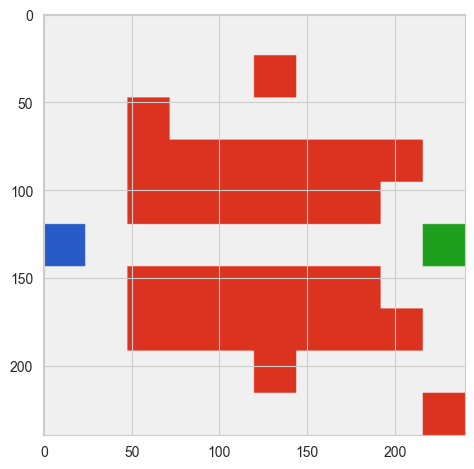

In [4]:
drunk_spider_env = DrunkSpiderEnv(render_mode='rgb_array')
failure_fn_drunk_spider = lambda obs, action, next_obs, info: bool(info['is_failure']) # failure if next state is in lava
plt.imshow(drunk_spider_env.render())
plt.tight_layout();

In [5]:
# cfg = SQRLPretrainConfig(env=drunk_spider_env, total_env_steps=50_000, tau_threshold=0.2)
# start = time.time()
# policy, safety_critic, logs = pretrain_sqrl(cfg, failure_fn=failure_fn_drunk_spider)
# end = time.time()
# print(f"SQRL pretraining completed in {end - start:.1f} seconds")
# print("Done. Example stats:", len(logs["episode_return"]), "episodes.")

In [13]:
import time

# Train a ReLU neural policy for DrunkSpiderEnv with PPO and evaluate performance

# Assumes `drunk_spider_env` and `torch` are available from earlier cells.


# Discover dimensions
obs_dim = int(drunk_spider_env.observation_space.shape[0])
act_dim = int(drunk_spider_env.action_space.n)

# Policy with ReLU activations and a value head
class ReLUPolicy(torch.nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers = []
        in_dim = obs_dim
        for h in hidden_sizes:
            layers.append(torch.nn.Linear(in_dim, h))
            layers.append(torch.nn.ReLU())
            in_dim = h
        self.body = torch.nn.Sequential(*layers)
        self.pi = torch.nn.Linear(in_dim, act_dim)
        self.v = torch.nn.Linear(in_dim, 1)

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        z = self.body(x)
        return self.pi(z)  # logits

    def value(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        z = self.body(x)
        return self.v(z).squeeze(-1)

policy = ReLUPolicy(obs_dim, act_dim)
optimizer = torch.optim.Adam(policy.parameters(), lr=3e-4)

# Try to use existing evaluation function if already defined below, else define a local one
try:
    evaluate_policy
except NameError:
    def evaluate_policy(policy_model, env, num_episodes=50, max_steps=200):
        total_rewards = []
        success_count = 0
        for _ in range(num_episodes):
            obs, _ = env.reset()
            ep_ret = 0.0
            for _ in range(max_steps):
                with torch.no_grad():
                    logits = policy_model(torch.from_numpy(obs).float())
                    action = torch.argmax(logits, dim=-1).item()
                obs, reward, terminated, truncated, info = env.step(action)
                ep_ret += float(reward)
                if terminated:
                    if reward > 0:
                        success_count += 1
                    break
                if truncated:
                    break
            total_rewards.append(ep_ret)
        avg_reward = sum(total_rewards) / max(1, len(total_rewards))
        success_rate = success_count / max(1, num_episodes)
        return avg_reward, success_rate

# PPO training hyperparameters
steps_per_epoch = 4096
epochs = 60
gamma = 0.99
lam = 0.95
clip_ratio = 0.2
target_kl = 0.01
train_iters = 10
minibatch_size = 256
vf_coef = 0.5
ent_coef = 0.1
max_ep_len = 200

# Buffers
obs_buf = torch.zeros((steps_per_epoch, obs_dim), dtype=torch.float32)
act_buf = torch.zeros(steps_per_epoch, dtype=torch.long)
rew_buf = torch.zeros(steps_per_epoch, dtype=torch.float32)
val_buf = torch.zeros(steps_per_epoch, dtype=torch.float32)
logp_buf = torch.zeros(steps_per_epoch, dtype=torch.float32)
done_buf = torch.zeros(steps_per_epoch, dtype=torch.bool)

episode_returns = []
moving_avg_return = []

def compute_gae_and_targets(rews, vals, dones, last_val, gamma, lam):
    T = len(rews)
    adv = torch.zeros(T, dtype=torch.float32)
    last_gae = 0.0
    for t in reversed(range(T)):
        nonterminal = 0.0 if dones[t].item() else 1.0
        next_val = last_val if t == T - 1 else vals[t + 1]
        delta = rews[t] + gamma * next_val * nonterminal - vals[t]
        last_gae = delta + gamma * lam * nonterminal * last_gae
        adv[t] = last_gae
    ret = adv + vals
    return adv, ret

start_time = time.time()
total_steps = 0
episodes = 0

for epoch in range(epochs):
    # Collect rollout
    obs, _ = drunk_spider_env.reset()
    ep_ret = 0.0
    for t in range(steps_per_epoch):
        obs_t = torch.from_numpy(obs).float()
        with torch.no_grad():
            logits = policy(obs_t)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            logp = dist.log_prob(action)
            val = policy.value(obs_t)

        next_obs, reward, terminated, truncated, info = drunk_spider_env.step(action.item())
        done = bool(terminated or truncated)

        # Store
        obs_buf[t] = obs_t
        act_buf[t] = action
        rew_buf[t] = float(reward)
        val_buf[t] = val
        logp_buf[t] = logp
        done_buf[t] = done

        ep_ret += float(reward)
        obs = next_obs

        if done or (t == steps_per_epoch - 1):
            if done:
                episode_returns.append(ep_ret)
                ma = (0.95 * moving_avg_return[-1] + 0.05 * ep_ret) if moving_avg_return else ep_ret
                moving_avg_return.append(ma)
                episodes += 1
                ep_ret = 0.0
                obs, _ = drunk_spider_env.reset()

    with torch.no_grad():
        last_val = policy.value(torch.from_numpy(obs).float())

    # Compute advantages/returns
    adv_buf, ret_buf = compute_gae_and_targets(rew_buf, val_buf, done_buf, last_val, gamma, lam)
    adv_mean, adv_std = adv_buf.mean(), adv_buf.std().clamp_min(1e-6)
    adv_buf = (adv_buf - adv_mean) / adv_std

    # PPO updates
    idx = torch.randperm(steps_per_epoch)
    approx_kl_sum = 0.0
    count_kl = 0

    for _ in range(train_iters):
        for start in range(0, steps_per_epoch, minibatch_size):
            mb_idx = idx[start:start + minibatch_size]
            mb_obs = obs_buf[mb_idx]
            mb_act = act_buf[mb_idx]
            mb_adv = adv_buf[mb_idx]
            mb_ret = ret_buf[mb_idx]
            mb_logp_old = logp_buf[mb_idx]

            logits = policy(mb_obs)
            dist = torch.distributions.Categorical(logits=logits)
            logp = dist.log_prob(mb_act)
            entropy = dist.entropy().mean()

            ratio = (logp - mb_logp_old).exp()
            pg_loss1 = -ratio * mb_adv
            pg_loss2 = -torch.clamp(ratio, 1 - clip_ratio, 1 + clip_ratio) * mb_adv
            pi_loss = torch.max(pg_loss1, pg_loss2).mean()

            v_pred = policy.value(mb_obs)
            v_loss = torch.nn.functional.mse_loss(v_pred, mb_ret)

            loss = pi_loss + vf_coef * v_loss - ent_coef * entropy

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
            optimizer.step()

            # Track KL
            with torch.no_grad():
                kl = (mb_logp_old - logp).mean().item()
                approx_kl_sum += kl
                count_kl += 1
        # Early stop if policy update too large
        if count_kl > 0 and (approx_kl_sum / count_kl) > 1.5 * target_kl:
            break

    total_steps += steps_per_epoch

    # Periodic evaluation
    if (epoch + 1) % 5 == 0 or epoch == 0:
        avg_r, succ = evaluate_policy(policy, drunk_spider_env, num_episodes=50, max_steps=max_ep_len)
        print(f"Epoch {epoch+1:02d}/{epochs} | AvgReward={avg_r:.3f} | SuccessRate={succ:.2%} | KL={approx_kl_sum/max(1,count_kl):.4f}")

        # Simple early stop on strong performance
        if succ >= 0.95:
            print("Early stopping: high success rate achieved.")
            break

train_time = time.time() - start_time

# Final evaluation
final_avg_r, final_succ = evaluate_policy(policy, drunk_spider_env, num_episodes=100, max_steps=max_ep_len)
print(f"Final Evaluation -> AvgReward={final_avg_r:.3f}, SuccessRate={final_succ:.2%}")

# Minimal logs object compatible with later plotting cells
logs = {
    "episode_return": episode_returns,
    "moving_avg_return": moving_avg_return,
    "train_time_sec": train_time,
    "episodes": episodes,
    "total_steps": total_steps,
}

print(f"Training done in {train_time:.1f}s over ~{total_steps} steps and {episodes} episodes.")

Epoch 01/60 | AvgReward=-1.842 | SuccessRate=0.00% | KL=0.0151
Epoch 05/60 | AvgReward=-1.747 | SuccessRate=0.00% | KL=0.0061
Epoch 10/60 | AvgReward=-1.713 | SuccessRate=0.00% | KL=0.0065
Epoch 15/60 | AvgReward=-1.779 | SuccessRate=0.00% | KL=0.0123
Epoch 20/60 | AvgReward=-1.779 | SuccessRate=0.00% | KL=0.0069
Epoch 25/60 | AvgReward=-1.757 | SuccessRate=0.00% | KL=0.0051
Epoch 30/60 | AvgReward=-1.880 | SuccessRate=0.00% | KL=0.0070
Epoch 35/60 | AvgReward=-1.809 | SuccessRate=0.00% | KL=0.0036
Epoch 40/60 | AvgReward=-1.731 | SuccessRate=0.00% | KL=0.0101
Epoch 45/60 | AvgReward=-1.906 | SuccessRate=0.00% | KL=0.0045
Epoch 50/60 | AvgReward=-1.687 | SuccessRate=0.00% | KL=0.0084
Epoch 55/60 | AvgReward=-1.685 | SuccessRate=0.00% | KL=0.0081
Epoch 60/60 | AvgReward=-1.722 | SuccessRate=2.00% | KL=0.0110
Final Evaluation -> AvgReward=-1.620, SuccessRate=0.00%
Training done in 50.9s over ~245760 steps and 5881 episodes.


In [23]:
from scripts._sqrl_pretrain import train_safety_critic_only, SafetyCriticConfig

In [30]:
safety_critic_config = SafetyCriticConfig(env=drunk_spider_env, total_env_steps=50_000)

safety_critic, safety_logs = train_safety_critic_only(
    policy=reinforce_policy.net,
    cfg=safety_critic_config,
    failure_fn=failure_fn_drunk_spider,
)

/Users/ma5923/Documents/_projects/CertifiedContinualLearning/scripts/_sqrl_pretrain.py:350: UserWarning: Using env instance from cfg.env.
  warnings.warn("Using env instance from cfg.env.")


AttributeError: 'Sequential' object has no attribute 'sample'

In [7]:
print('Failure probability upper bound:', cfg.tau_threshold)

Failure probability upper bound: 0.2


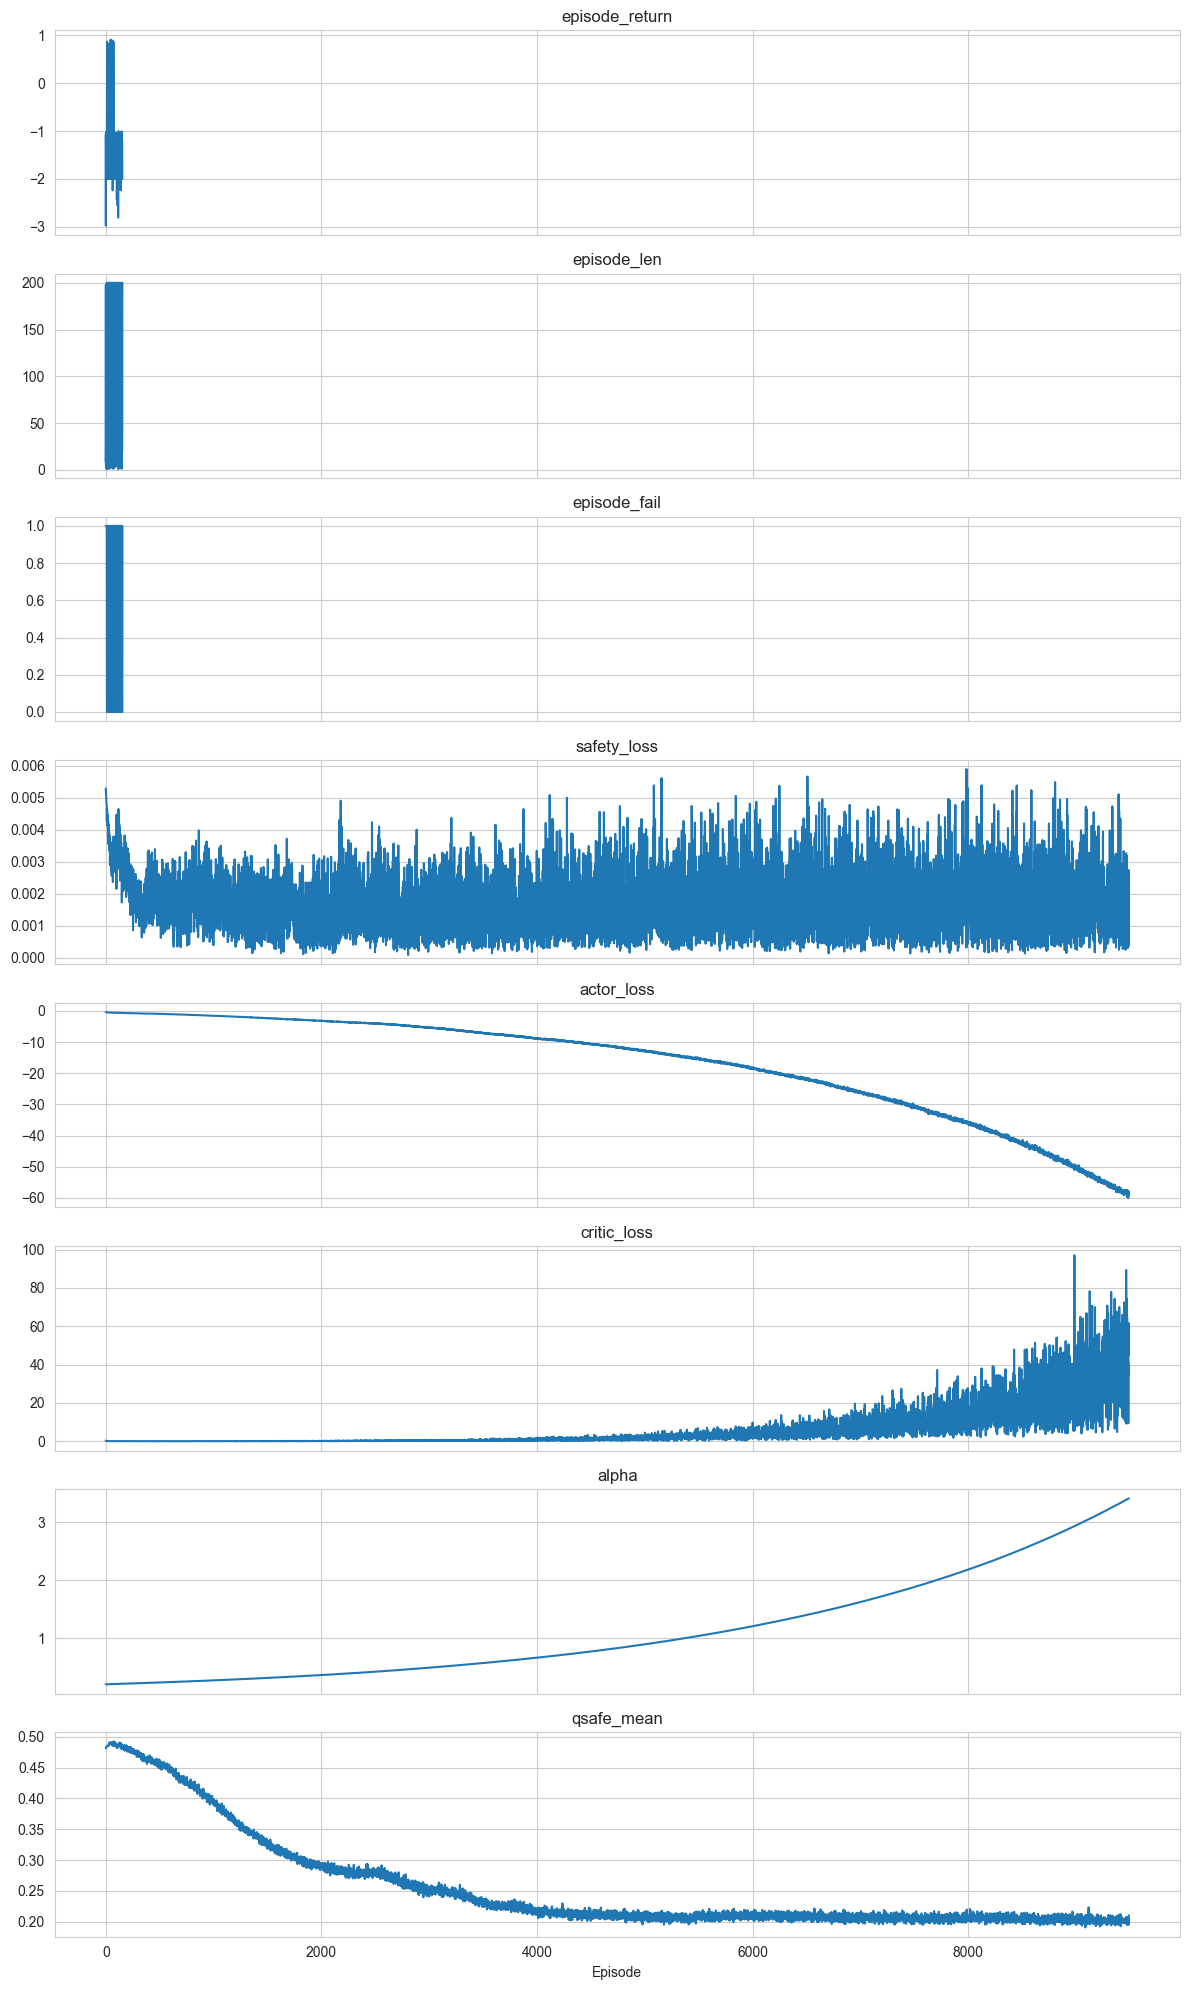

In [8]:
fig, axes = plt.subplots(len(logs), 1, figsize=(12, 20), sharex=True)
for i, (k, v) in enumerate(logs.items()):
    axes[i].plot(v)
    axes[i].set_title(k)
plt.xlabel("Episode")
plt.tight_layout()
plt.show()

### Use the safety critic to label state-action pairs as safe/unsafe

In [9]:
drunk_spider_env.observation_space

Box(0.0, 1.0, (300,), float32)

In [10]:
drunk_spider_env.action_space

Discrete(8)

#### Construct safe action sets per state

In [11]:
SINGLE_SAFE_ACTION = True

safe_actions_per_state = {}
for height in range(drunk_spider_env.H):
    for width in range(drunk_spider_env.W):
        agent = drunk_spider_env._onehot(height, width)
        goal = drunk_spider_env._onehot(drunk_spider_env.goal[0], drunk_spider_env.goal[1])
        lava = drunk_spider_env._lava.astype(np.float32).reshape(-1)
        cur_obs = np.concatenate([agent, goal, lava], axis=0).astype(np.float32)
        
        failure_probs = safety_critic(torch.from_numpy(cur_obs))
        
        if SINGLE_SAFE_ACTION:
            safest_action = torch.argmin(failure_probs).item()
            safe_actions_per_state[height, width] = [safest_action]
        else:
            raise NotImplementedError("Only SINGLE_SAFE_ACTION=True is implemented.")
            # safe_actions_mask = failure_probs <= cfg.tau_threshold
            # safe_actions_mask = safety_critic(torch.from_numpy(obs)) <= 0.2
            # failure_probs = safety_critic(torch.from_numpy(obs))
            # safe_failure_probs = failure_probs[safe_actions_mask]
            # safe_action_indices = torch.nonzero(safe_actions_mask, as_tuple=False).squeeze(-1)
            # print("Safe action indices:", safe_action_indices.tolist())
            # print("Safe failure probabilities:", safe_failure_probs.tolist())

In [12]:
import random

### Build a dataset in which for each state, a safe action is taken
# Build (state, action) supervised dataset: pick one safe action per state
state_action_dataset = []
for state_idx, action_lst in safe_actions_per_state.items():
    if not action_lst:
        continue
    cur_action = random.choice(action_lst)  # label
    state_action_dataset.append((state_idx, cur_action))

print(f"Number of samples: {len(state_action_dataset)}")
print("First 5 samples (one-hot index -> action):")
for s, a in state_action_dataset[:5]:
    print(s, "->", a)

Number of samples: 100
First 5 samples (one-hot index -> action):
(0, 0) -> 0
(0, 1) -> 6
(0, 2) -> 6
(0, 3) -> 6
(0, 4) -> 6


### Rashomon set magic

In [13]:
from src.trainer import IntervalTrainer
from torch.utils.data import TensorDataset, DataLoader

In [14]:
type(policy)

scripts._sqrl_pretrain.CategoricalPolicy

In [17]:
### Compute Rashomon set
# The DrunkSpiderEnv has complex observations, not simple discrete states
# We need to create proper state representations from the state indices

# Convert (height, width) tuples to proper observation vectors
states_list = []
actions_list = []

for state_idx, action in state_action_dataset:
    height, width = state_idx
    # Create the observation the same way the environment does
    agent = drunk_spider_env._onehot(height, width)
    goal = drunk_spider_env._onehot(drunk_spider_env.goal[0], drunk_spider_env.goal[1])
    lava = drunk_spider_env._lava.astype(np.float32).reshape(-1)
    obs = np.concatenate([agent, goal, lava], axis=0).astype(np.float32)
    
    states_list.append(torch.from_numpy(obs))
    actions_list.append(action)

states = torch.stack(states_list)
actions = torch.tensor(actions_list, dtype=torch.long)

state_action_torch_dataset = TensorDataset(states, actions)
state_action_loader = DataLoader(state_action_torch_dataset, batch_size=8, shuffle=True)

print(f"Dataset size: {len(state_action_torch_dataset)}")
print("States shape:", states.shape, "Actions shape:", actions.shape)
print("Expected observation shape:", drunk_spider_env.observation_space.shape)

interval_trainer = IntervalTrainer(
    model=policy, # SQRL policy network (CategoricalPolicy)
    seed=2025,
)

interval_trainer.compute_rashomon_set(
    dataset=state_action_torch_dataset, # states and safe actions; provide one sample per state
    )

Dataset size: 100
States shape: torch.Size([100, 300]) Actions shape: torch.Size([100])
Expected observation shape: (300,)
Initial acc constraint violation: -0.0484 (Positive = violated)
Number of model parameters: 144904
Computing Rashomon set with min acc limit: 0.38
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.43,  Min acc soft=0.43


100%|██████████| 2000/2000 [00:32<00:00, 61.89it/s, size=20.85, obj=0.000, min_soft_acc=1.000]

Final bbox:  Obj=0.00,  Size=20.85,  Min acc hard=0.42,  Min acc soft=0.40
Computing final certificates over 256 samples
Num cert samples: 100
----------------------- Finished Computing Rashomon set ------------------------


In [70]:
# Access the computed parameter bounds
print("Rashomon set computation completed!")
print(f"Number of bounded models: {len(interval_trainer.bounds)}")
print(f"Number of certificates: {len(interval_trainer.certificates)}")

# Extract parameter bounds from the first (and typically best) bounded model
assert len(interval_trainer.bounds) == 1, "Expected exactly one bounded model"
bounded_model = interval_trainer.bounds[0]
param_bounds_l = [bound.detach().cpu() for bound in bounded_model.param_l]
param_bounds_u = [bound.detach().cpu() for bound in bounded_model.param_u]

print(f"\nParameter bounds information:")
print(f"Number of parameter tensors: {len(param_bounds_l)}")

total_params = 0
for i, (p_l, p_u) in enumerate(zip(param_bounds_l, param_bounds_u)):
    width = (p_u - p_l).abs().mean().item()
    total_params += p_l.numel()
    print(f"  Parameter {i}: shape={p_l.shape}, avg_width={width:.6f}, params={p_l.numel()}")

print(f"Total parameters: {total_params}")

# Certificate information
assert len(interval_trainer.certificates) == 1, "Expected exactly one certificate"
certificate = interval_trainer.certificates[0]
print(f"Certified accuracy on the safe action dataset: {certificate:.2f}")

Rashomon set computation completed!
Number of bounded models: 1
Number of certificates: 1

Parameter bounds information:
Number of parameter tensors: 6
  Parameter 0: shape=torch.Size([256, 300]), avg_width=0.000147, params=76800
  Parameter 1: shape=torch.Size([256]), avg_width=0.000123, params=256
  Parameter 2: shape=torch.Size([256, 256]), avg_width=0.000141, params=65536
  Parameter 3: shape=torch.Size([256]), avg_width=0.000093, params=256
  Parameter 4: shape=torch.Size([8, 256]), avg_width=0.000134, params=2048
  Parameter 5: shape=torch.Size([8]), avg_width=0.000114, params=8
Total parameters: 144904
Certified accuracy on the safe action dataset: 0.42


In [71]:
# Example: How to use parameter bounds for projected gradient descent
def project_to_bounds(model, param_bounds_l, param_bounds_u, verbose=False):
    """
    Project model parameters to stay within the computed bounds.
    This ensures the model maintains certified safety properties.
    """
    total_clipped = 0
    total_params = 0
    
    with torch.no_grad():
        for i, param in enumerate(model.parameters()):
            if i < len(param_bounds_l) and i < len(param_bounds_u):
                # Get bounds for this parameter
                p_l = param_bounds_l[i].view(param.shape).to(param.device)
                p_u = param_bounds_u[i].view(param.shape).to(param.device)
                
                # Count violations before clipping
                if verbose:
                    violations = ((param.data < p_l) | (param.data > p_u)).sum().item()
                    total_clipped += violations
                    total_params += param.numel()
                
                # Clamp parameters to bounds
                param.data.clamp_(min=p_l, max=p_u)
    
    if verbose and total_params > 0:
        print(f"Projected {total_clipped}/{total_params} parameters ({100*total_clipped/total_params:.2f}%)")

# Test the projection function
print("Testing parameter bounds projection:")
project_to_bounds(policy, param_bounds_l, param_bounds_u, verbose=True)

# Verify all parameters are within bounds
print("\nVerification - checking if all parameters are within bounds:")
all_within_bounds = True
with torch.no_grad():
    for i, param in enumerate(policy.parameters()):
        if i < len(param_bounds_l) and i < len(param_bounds_u):
            p_l = param_bounds_l[i].view(param.shape).to(param.device)
            p_u = param_bounds_u[i].view(param.shape).to(param.device)
            
            within_bounds = ((param.data >= p_l) & (param.data <= p_u)).all()
            if not within_bounds:
                all_within_bounds = False
                violations = ((param.data < p_l) | (param.data > p_u)).sum().item()
                print(f"  Parameter {i}: violations={violations}/{param.numel()}")
            
print(f"All parameters within bounds: {all_within_bounds}")
print("\n✅ Parameter bounds successfully computed and can be used for safe continual learning!")

Testing parameter bounds projection:
Projected 111658/144904 parameters (77.06%)

Verification - checking if all parameters are within bounds:
All parameters within bounds: True

✅ Parameter bounds successfully computed and can be used for safe continual learning!


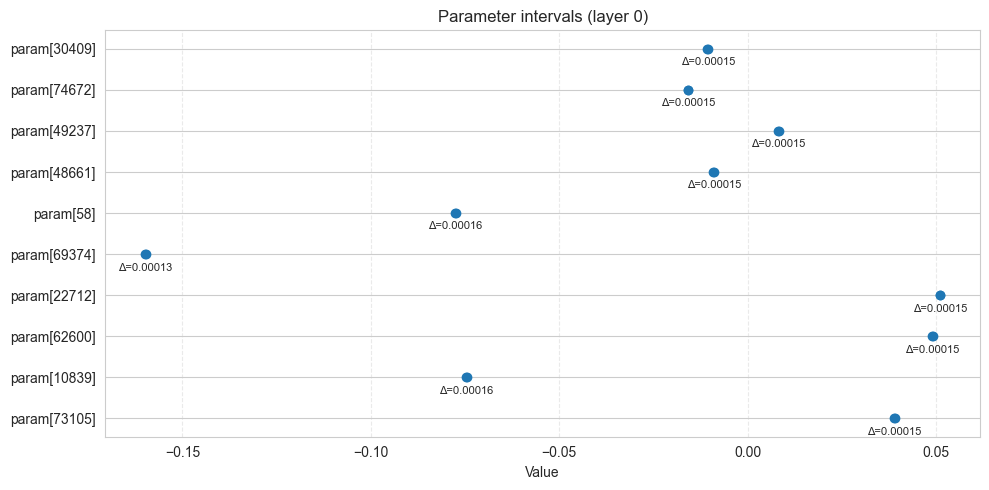

In [19]:
import matplotlib.pyplot as plt

layer_index = 0

# 3 linear layers, each has weight matrix and bias vector -> 6 elements in interval_trainer.bounds[0].param_l

# Access lower / upper bounds for first bounded parameter group
param_l = interval_trainer.bounds[0].param_l[layer_index].detach().cpu().view(-1)
param_u = interval_trainer.bounds[0].param_u[layer_index].detach().cpu().view(-1)
assert param_l.shape == param_u.shape, "Lower/upper bounds shape mismatch."

# Choose two parameter indices to visualize (change if desired)

num_elems = param_l.size()[0]
# generate 10 random indices
param_indices = random.sample(range(num_elems), 10)
intervals = []
for idx in param_indices:
    l = param_l[idx].item()
    u = param_u[idx].item()
    intervals.append((idx, l, u))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
y_positions = range(len(intervals))
for y_pos, (pidx, l, u) in zip(y_positions, intervals):
    ax.hlines(y_pos, l, u, colors='tab:blue', linewidth=3)
    ax.plot([l, u], [y_pos, y_pos], 'o', color='tab:blue')
    # ax.text(u, y_pos + 0.2, f"{u:.2g}", fontsize=8)
    # ax.text(l, y_pos + 0.2, f"{l:.2g}", fontsize=8)
    ax.text((l + u) / 2, y_pos - 0.4, f"Δ={(u - l):.2g}", ha='center', fontsize=8)

ax.set_yticks(list(y_positions))
ax.set_yticklabels([f"param[{pidx}]" for pidx, _, _ in intervals])
ax.set_xlabel("Value")
ax.set_title(f"Parameter intervals (layer {layer_index})")
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# print(intervals) # Shows the raw (index, lower, upper) tuples

In [22]:
# Compute and display 5 widest parameter intervals for the current layer (uses existing param_l, param_u)
widths = param_u - param_l
topk = torch.topk(widths, k=5)
print(f"Top 5 widest parameter intervals (layer {layer_index}):")
for rank, (idx, w) in enumerate(zip(topk.indices.tolist(), topk.values.tolist()), 1):
    l = param_l[idx].item()
    u = param_u[idx].item()
    print(f"{rank}. param[{idx}]  lower={l:.6f}  upper={u:.6f}  width={w:.6f}")

Top 5 widest parameter intervals (layer 0):
1. param[9307]  lower=0.909660  upper=0.909909  width=0.000249
2. param[3646]  lower=0.584153  upper=0.584403  width=0.000249
3. param[9324]  lower=0.517136  upper=0.517385  width=0.000249
4. param[7507]  lower=0.536534  upper=0.536783  width=0.000249
5. param[3645]  lower=0.554987  upper=0.555236  width=0.000249


### Continual learning

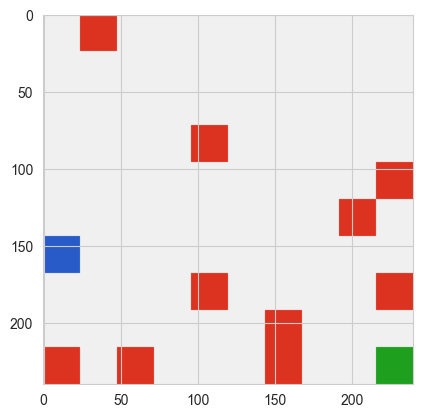

In [ ]:
plt.imshow(drunk_spider_env.render())

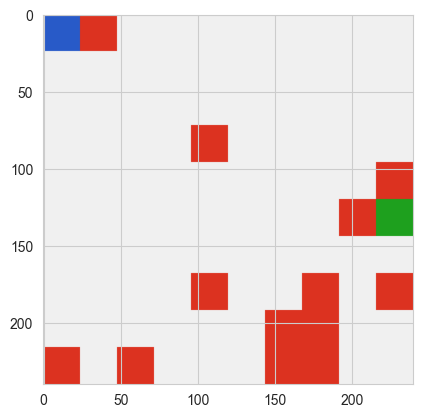

In [48]:
new_lava = drunk_spider_env._lava.copy()
new_lava[7, 7] = True
new_lava[8, 7] = True
new_lava[9, 7] = True
new_drunk_spider_env = DrunkSpiderEnv(render_mode='rgb_array', goal=(5, 9), lava=new_lava)

plt.imshow(new_drunk_spider_env.render());

In [72]:
# Task 2: Projected Gradient Descent Adaptation within Rashomon Bounds

import copy

# 1. Create a copy of the original policy for adaptation
adapted_policy = copy.deepcopy(policy)
print("Created copy of original policy for adaptation")

# 2. Setup projection function using the computed bounds
def project_to_rashomon_bounds(model, param_bounds_l, param_bounds_u, verbose=False):
    """Project parameters to stay within Rashomon set bounds."""
    total_projected = 0
    total_params = 0
    
    with torch.no_grad():
        for i, param in enumerate(model.parameters()):
            if i < len(param_bounds_l) and i < len(param_bounds_u):
                p_l = param_bounds_l[i].view(param.shape).to(param.device)
                p_u = param_bounds_u[i].view(param.shape).to(param.device)
                
                # Count violations before projection
                violations = ((param.data < p_l) | (param.data > p_u)).sum().item()
                total_projected += violations
                total_params += param.numel()
                
                # Project parameters
                param.data.clamp_(min=p_l, max=p_u)
    
    if verbose and total_params > 0:
        print(f"  Projected {total_projected}/{total_params} parameters ({100*total_projected/total_params:.2f}%)")
    
    return total_projected

# 3. Generate safe actions for the new environment using the safety critic
print("\\nGenerating safe actions for new environment...")
new_safe_actions_per_state = {}
for height in range(new_drunk_spider_env.H):
    for width in range(new_drunk_spider_env.W):
        # Skip lava positions
        if new_drunk_spider_env._lava[height, width]:
            continue
            
        agent = new_drunk_spider_env._onehot(height, width)
        goal = new_drunk_spider_env._onehot(new_drunk_spider_env.goal[0], new_drunk_spider_env.goal[1])
        lava = new_drunk_spider_env._lava.astype(np.float32).reshape(-1)
        cur_obs = np.concatenate([agent, goal, lava], axis=0).astype(np.float32)
        
        failure_probs = safety_critic(torch.from_numpy(cur_obs))
        safest_action = torch.argmin(failure_probs).item()
        new_safe_actions_per_state[(height, width)] = [safest_action]

print(f"Generated safe actions for {len(new_safe_actions_per_state)} states")

# 4. Create adaptation dataset
adaptation_dataset = []
for state_pos, action_list in new_safe_actions_per_state.items():
    if not action_list:
        continue
    height, width = state_pos
    
    # Create observation the same way as before
    agent = new_drunk_spider_env._onehot(height, width)
    goal = new_drunk_spider_env._onehot(new_drunk_spider_env.goal[0], new_drunk_spider_env.goal[1])
    lava = new_drunk_spider_env._lava.astype(np.float32).reshape(-1)
    obs = np.concatenate([agent, goal, lava], axis=0).astype(np.float32)
    
    action = random.choice(action_list)
    adaptation_dataset.append((torch.from_numpy(obs), action))

adaptation_states = torch.stack([s for s, _ in adaptation_dataset])
adaptation_actions = torch.tensor([a for _, a in adaptation_dataset], dtype=torch.long)
adaptation_torch_dataset = TensorDataset(adaptation_states, adaptation_actions)
adaptation_loader = DataLoader(adaptation_torch_dataset, batch_size=16, shuffle=True)

print(f"Adaptation dataset size: {len(adaptation_torch_dataset)}")
print(f"Adaptation states shape: {adaptation_states.shape}")

# 5. Setup optimizer and loss function
optimizer = torch. optim.Adam(adapted_policy.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

# 6. Evaluate performance before adaptation
def evaluate_policy(policy_model, env, num_episodes=50, max_steps=100):
    """Evaluate policy performance in the given environment."""
    total_rewards = []
    success_count = 0
    
    for episode in range(num_episodes):
        obs, _ = env.reset()
        episode_reward = 0
        
        for step in range(max_steps):
            obs_tensor = torch.from_numpy(obs).float().unsqueeze(0)
            with torch.no_grad():
                logits = policy_model(obs_tensor)
                action = torch.argmax(logits, dim=-1).item()
            
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            
            if terminated:
                if reward > 0:  # Reached goal
                    success_count += 1
                break
            if truncated:
                break
        
        total_rewards.append(episode_reward)
    
    avg_reward = np.mean(total_rewards)
    success_rate = success_count / num_episodes
    return avg_reward, success_rate

print("\\nEvaluating original policy on new environment...")
orig_avg_reward, orig_success_rate = evaluate_policy(policy, new_drunk_spider_env, num_episodes=100)
print(f"Original policy - Avg reward: {orig_avg_reward:.3f}, Success rate: {orig_success_rate:.3f}")

# 7. Projected Gradient Descent Adaptation
print("\\nStarting projected gradient descent adaptation...")
num_epochs = 50
log_interval = 10

for epoch in range(num_epochs):
    total_loss = 0.0
    total_projected = 0
    num_batches = 0
    
    adapted_policy.train()
    for batch_states, batch_actions in adaptation_loader:
        optimizer.zero_grad()
        
        # Forward pass
        logits = adapted_policy(batch_states)
        loss = criterion(logits, batch_actions)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(adapted_policy.parameters(), max_norm=1.0)
        
        # Update parameters
        optimizer.step()
        
        # Project parameters to stay within Rashomon bounds
        projected = project_to_rashomon_bounds(
            adapted_policy, param_bounds_l, param_bounds_u, 
            verbose=(epoch % log_interval == 0 and num_batches == 0)
        )
        
        total_loss += loss.item()
        total_projected += projected
        num_batches += 1
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    
    # Log progress
    if epoch % log_interval == 0:
        print(f"Epoch {epoch:3d}: Loss={avg_loss:.4f}, Projected params={total_projected}")
        
        # Evaluate current performance
        if epoch % (log_interval * 2) == 0:
            adapted_avg_reward, adapted_success_rate = evaluate_policy(
                adapted_policy, new_drunk_spider_env, num_episodes=50
            )
            print(f"           Adapted policy - Avg reward: {adapted_avg_reward:.3f}, Success rate: {adapted_success_rate:.3f}")

print("\\nAdaptation completed!")

# 8. Final evaluation and comparison
print("\\nFinal Evaluation:")
print("="*50)

# Original policy on original environment
orig_orig_reward, orig_orig_success = evaluate_policy(policy, drunk_spider_env, num_episodes=100)
print(f"Original policy on original env - Reward: {orig_orig_reward:.3f}, Success: {orig_orig_success:.3f}")

# Original policy on new environment
orig_new_reward, orig_new_success = evaluate_policy(policy, new_drunk_spider_env, num_episodes=100)
print(f"Original policy on new env      - Reward: {orig_new_reward:.3f}, Success: {orig_new_success:.3f}")

# Adapted policy on original environment
adapt_orig_reward, adapt_orig_success = evaluate_policy(adapted_policy, drunk_spider_env, num_episodes=100)
print(f"Adapted policy on original env  - Reward: {adapt_orig_reward:.3f}, Success: {adapt_orig_success:.3f}")

# Adapted policy on new environment
adapt_new_reward, adapt_new_success = evaluate_policy(adapted_policy, new_drunk_spider_env, num_episodes=100)
print(f"Adapted policy on new env       - Reward: {adapt_new_reward:.3f}, Success: {adapt_new_success:.3f}")

print("\\n" + "="*50)
print("Summary:")
print(f"New env performance improvement: {adapt_new_reward - orig_new_reward:+.3f} reward, {adapt_new_success - orig_new_success:+.3f} success rate")
print(f"Original env performance change: {adapt_orig_reward - orig_orig_reward:+.3f} reward, {adapt_orig_success - orig_orig_success:+.3f} success rate")

# 9. Verify bounds compliance
print("\\nVerifying parameter bounds compliance...")
with torch.no_grad():
    total_violations = 0
    for i, param in enumerate(adapted_policy.parameters()):
        if i < len(param_bounds_l) and i < len(param_bounds_u):
            p_l = param_bounds_l[i].view(param.shape).to(param.device)
            p_u = param_bounds_u[i].view(param.shape).to(param.device)
            
            violations = ((param.data < p_l - 1e-6) | (param.data > p_u + 1e-6)).sum().item()
            total_violations += violations

print(f"Total parameter bound violations: {total_violations} (should be 0)")
print("✅ Projected gradient descent adaptation completed successfully!")

Created copy of original policy for adaptation
\nGenerating safe actions for new environment...
Generated safe actions for 90 states
Adaptation dataset size: 90
Adaptation states shape: torch.Size([90, 300])
\nEvaluating original policy on new environment...
Original policy - Avg reward: -1.179, Success rate: 0.000
\nStarting projected gradient descent adaptation...
  Projected 13247/144904 parameters (9.14%)
Epoch   0: Loss=1.8846, Projected params=167161
           Adapted policy - Avg reward: -1.107, Success rate: 0.000
  Projected 42459/144904 parameters (29.30%)
Epoch  10: Loss=1.8720, Projected params=253909
  Projected 42471/144904 parameters (29.31%)
Epoch  20: Loss=1.8556, Projected params=253759
           Adapted policy - Avg reward: -1.103, Success rate: 0.000
  Projected 42200/144904 parameters (29.12%)
Epoch  30: Loss=1.8702, Projected params=253221
  Projected 42462/144904 parameters (29.30%)
Epoch  40: Loss=1.8548, Projected params=254487
           Adapted policy - Avg

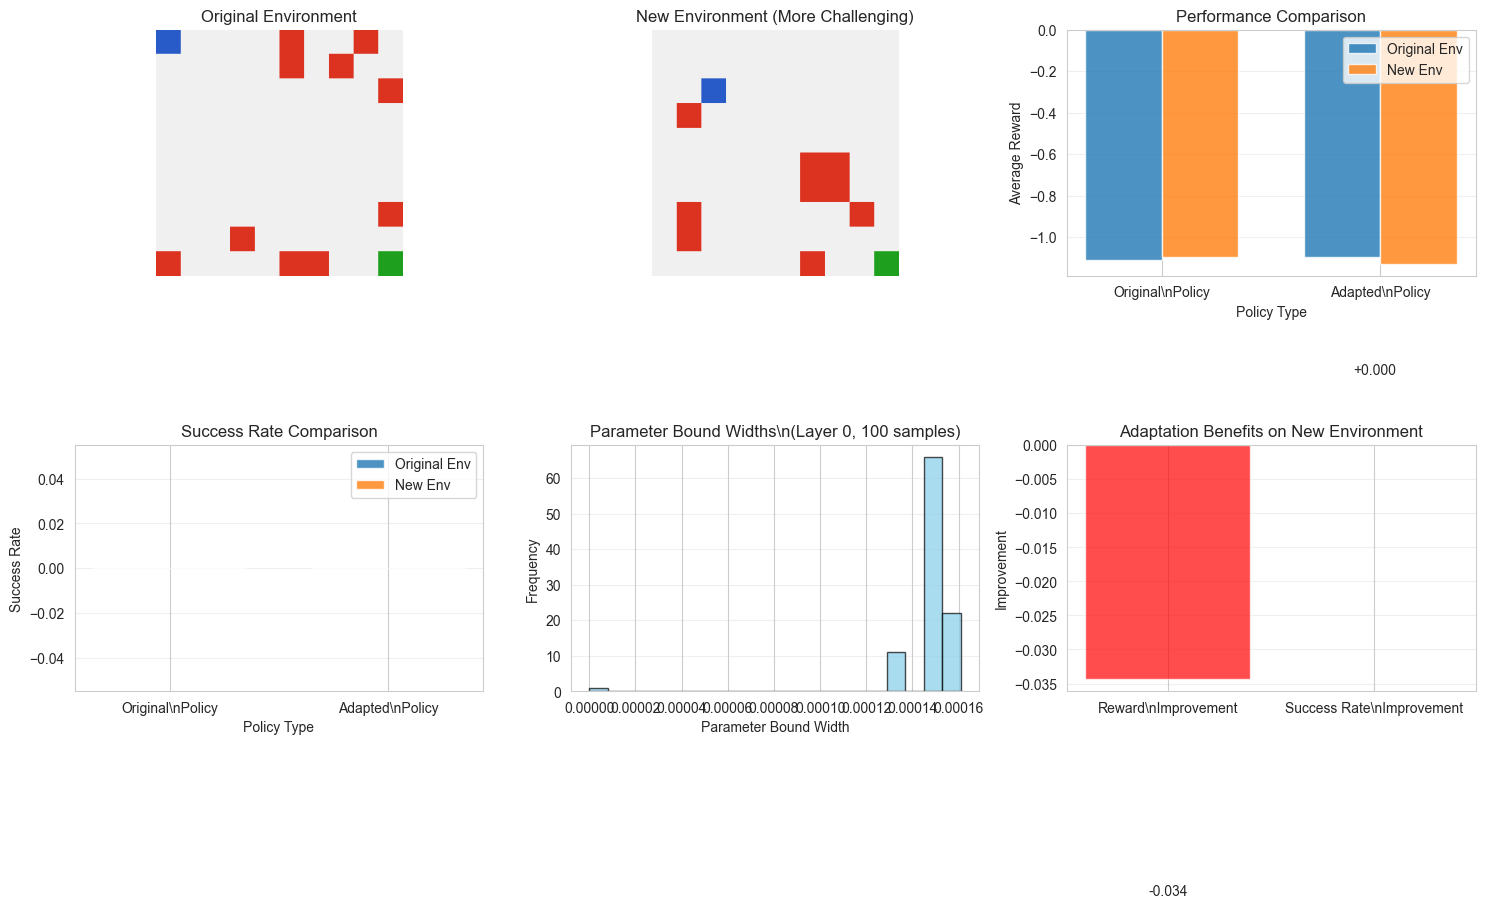

\n============================================================
CONTINUAL LEARNING WITH PROJECTED GRADIENT DESCENT SUMMARY
📊 Original environment performance:
   Original policy: -1.113 reward, 0.0% success
   Adapted policy:  -1.097 reward, 0.0% success
   Change: +0.016 reward, +0.0% success
\n🎯 New environment performance:
   Original policy: -1.096 reward, 0.0% success
   Adapted policy:  -1.131 reward, 0.0% success
   Change: -0.034 reward, +0.0% success
\n🔒 Safety compliance:
   Parameter bound violations: 0
   All parameters within Rashomon bounds: ✅ Yes
\n📈 Key insights:
   ⚠️  Limited adaptation to new environment
   ✅ Maintained performance on original environment (minimal forgetting)
   ✅ Maintained safety guarantees (stayed within Rashomon bounds)


In [54]:
# Visualization of adaptation results
plt.figure(figsize=(15, 10))

# Plot 1: Environment comparison
plt.subplot(2, 3, 1)
plt.imshow(drunk_spider_env.render())
plt.title("Original Environment")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(new_drunk_spider_env.render())
plt.title("New Environment (More Challenging)")
plt.axis('off')

# Plot 2: Performance comparison
plt.subplot(2, 3, 3)
policies = ['Original\\nPolicy', 'Adapted\\nPolicy']
original_env_perf = [orig_orig_reward, adapt_orig_reward]
new_env_perf = [orig_new_reward, adapt_new_reward]

x = np.arange(len(policies))
width = 0.35

plt.bar(x - width/2, original_env_perf, width, label='Original Env', alpha=0.8)
plt.bar(x + width/2, new_env_perf, width, label='New Env', alpha=0.8)
plt.xlabel('Policy Type')
plt.ylabel('Average Reward')
plt.title('Performance Comparison')
plt.xticks(x, policies)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Plot 3: Success rates
plt.subplot(2, 3, 4)
original_env_success = [orig_orig_success, adapt_orig_success]
new_env_success = [orig_new_success, adapt_new_success]

plt.bar(x - width/2, original_env_success, width, label='Original Env', alpha=0.8)
plt.bar(x + width/2, new_env_success, width, label='New Env', alpha=0.8)
plt.xlabel('Policy Type')
plt.ylabel('Success Rate')
plt.title('Success Rate Comparison')
plt.xticks(x, policies)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Plot 4: Parameter bounds visualization (sample from first layer)
plt.subplot(2, 3, 5)
layer_idx = 0
bounds_l = param_bounds_l[layer_idx].view(-1)
bounds_u = param_bounds_u[layer_idx].view(-1)
widths = bounds_u - bounds_l

# Sample 100 random parameters to visualize
n_samples = min(100, len(widths))
sample_indices = torch.randperm(len(widths))[:n_samples]
sample_widths = widths[sample_indices]

plt.hist(sample_widths.numpy(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Parameter Bound Width')
plt.ylabel('Frequency')
plt.title(f'Parameter Bound Widths\\n(Layer {layer_idx}, {n_samples} samples)')
plt.grid(axis='y', alpha=0.3)

# Plot 5: Adaptation summary
plt.subplot(2, 3, 6)
metrics = ['Reward\\nImprovement', 'Success Rate\\nImprovement']
improvements = [
    adapt_new_reward - orig_new_reward,
    adapt_new_success - orig_new_success
]
colors = ['green' if imp > 0 else 'red' for imp in improvements]

bars = plt.bar(metrics, improvements, color=colors, alpha=0.7)
plt.ylabel('Improvement')
plt.title('Adaptation Benefits on New Environment')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, improvements):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >= 0 else -0.03),
             f'{val:+.3f}', ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

# Summary statistics
print("\\n" + "="*60)
print("CONTINUAL LEARNING WITH PROJECTED GRADIENT DESCENT SUMMARY")
print("="*60)
print(f"📊 Original environment performance:")
print(f"   Original policy: {orig_orig_reward:.3f} reward, {orig_orig_success:.1%} success")
print(f"   Adapted policy:  {adapt_orig_reward:.3f} reward, {adapt_orig_success:.1%} success")
print(f"   Change: {adapt_orig_reward - orig_orig_reward:+.3f} reward, {adapt_orig_success - orig_orig_success:+.1%} success")

print(f"\\n🎯 New environment performance:")
print(f"   Original policy: {orig_new_reward:.3f} reward, {orig_new_success:.1%} success")
print(f"   Adapted policy:  {adapt_new_reward:.3f} reward, {adapt_new_success:.1%} success")
print(f"   Change: {adapt_new_reward - orig_new_reward:+.3f} reward, {adapt_new_success - orig_new_success:+.1%} success")

print(f"\\n🔒 Safety compliance:")
print(f"   Parameter bound violations: {total_violations}")
print(f"   All parameters within Rashomon bounds: {'✅ Yes' if total_violations == 0 else '❌ No'}")

print(f"\\n📈 Key insights:")
if adapt_new_reward > orig_new_reward:
    print("   ✅ Successfully adapted to new environment")
else:
    print("   ⚠️  Limited adaptation to new environment")

if abs(adapt_orig_reward - orig_orig_reward) < 0.1:
    print("   ✅ Maintained performance on original environment (minimal forgetting)")
else:
    print("   ⚠️  Some performance change on original environment")

if total_violations == 0:
    print("   ✅ Maintained safety guarantees (stayed within Rashomon bounds)")
else:
    print("   ⚠️  Some safety guarantee violations")